<a href="https://colab.research.google.com/github/AronJoseph96/AI-ML/blob/main/cifar10_cnn_classification_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [67]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print('Train shape: ', X_train.shape)
print('Test shape: ',X_test.shape)

Train shape:  (50000, 32, 32, 3)
Test shape:  (10000, 32, 32, 3)


In [68]:
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship','truck'
]

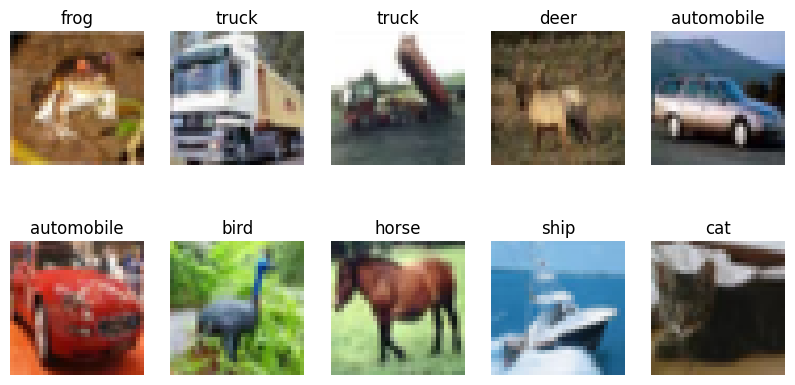

In [69]:
plt.figure(figsize=(10,5))

for i in range(10):
  plt.subplot(2, 5, i+1)
  plt.imshow(X_train[i])
  plt.title(class_names[y_train[i][0]])
  plt.axis('off')
plt.show()

In [70]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [71]:
# Step 4: Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    horizontal_flip=True
)

datagen.fit(X_train)

In [72]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(128, (3,3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(10, activation='softmax'))



In [73]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [74]:
#early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [75]:
history = model.fit(
    datagen.flow(X_train, y_train),
    epochs=20,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)


Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 41ms/step - accuracy: 0.4026 - loss: 1.6237 - val_accuracy: 0.5518 - val_loss: 1.2777
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.5457 - loss: 1.2816 - val_accuracy: 0.5901 - val_loss: 1.1661
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 42ms/step - accuracy: 0.5974 - loss: 1.1506 - val_accuracy: 0.6423 - val_loss: 1.0170
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.6311 - loss: 1.0654 - val_accuracy: 0.6744 - val_loss: 0.9317
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.6562 - loss: 1.0038 - val_accuracy: 0.6643 - val_loss: 0.9695
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.6731 - loss: 0.9466 - val_accuracy: 0.6890 - val_loss: 0.8908
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 39ms/step - accuracy: 0.6877 - loss: 0.9077 - val_accuracy: 0.7005 - val_loss: 0.8584
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.6976 -

In [76]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print('Test Accuracy: ',test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7568 - loss: 0.7338
Test Accuracy:  0.7567999958992004


In [77]:

pred = model.predict(X_test[:1])
predicted_class = np.argmax(pred)

print('Predicted: ', class_names[predicted_class])
print('Actual: ',class_names[y_test[0][0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Predicted:  cat
Actual:  cat


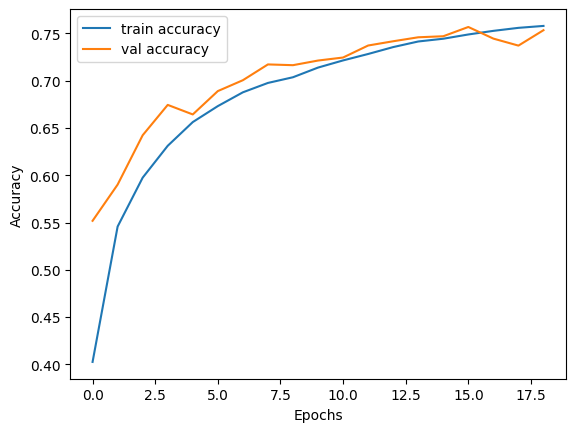

In [78]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()